In [9]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
import galsim
import os
from astropy.table import Table

from scipy.interpolate import interp1d
import scipy 

colors = {'u' : 'purple', 'g':'blue', 'r': 'green', 'i': 'orange', 'z' : 'magenta', 'y' : 'red'}


def apply_filter(wvl, data, band = 'g', rm_leakage = True):
    '''
    wvl - a list of the wavelengths in angstroms
    data - a N x M list of SEDs, N = number of SEDs, M = len of wvl
    returns data with the band filter applied to each SED
    '''
    
    filter_file = f'filter_files/total_{band}.dat'
    filter_band = np.loadtxt(filter_file).T #filter_band[0] -> wavelengths, filter_band[1] -> filter pass fraction

    # remove filter leakage: set lower bound of filter to 0.001 throughput
    if rm_leakage:
        leakage_mask = filter_band[1] < 0.001
        filter_band[1][leakage_mask] = np.zeros(np.sum(leakage_mask))
    
    func = interp1d(filter_band[0], filter_band[1])
    SED_filter = func(wvl)
    
    return data * SED_filter
    

#Pat and Josh's paper atmospheric conditions 
pressure=69.328
temperature=293.15
H2O_pressure=1.067


def apply_DCR(wave, filtered_data, zenith, pressure, temperature, H2O_pressure):
    '''
    wave - list of wavelength points
    filtered_data - dictionary, keys: bands, items: list of flux throughputs for each SED as viewed in that band 

    Takes in SED data with the filter throughputs already applied, returns refraction_angles (mapped from wave) and filtered_refracted_data (the flux density over refraction angles)

    '''
    dwvl = 0.1 #wavelength step
    wave_temp = np.arange(290, 1160, dwvl)

    #Get dR/dwavelength function
    refraction = galsim.dcr.get_refraction(
        wave_temp,
        zenith_angle=zenith * galsim.degrees,
        pressure=pressure,  # kPa
        temperature=temperature,  # K
        H2O_pressure=H2O_pressure,  # kPa
        ) * 180 * 3600 / np.pi #convert from radians to arcsec

    dR_dwvl = (refraction[1:] - refraction[0:-1])/dwvl
    wavelengths_midpoints = wave_temp[0:-1] + dwvl/2
    
    dRdwvl_func = interp1d(wavelengths_midpoints, dR_dwvl)

    #Get the refraction angle of each passed in wavelength 
    refraction_angles = galsim.dcr.get_refraction(
            wave,
            zenith_angle=zenith * galsim.degrees,
            pressure=pressure,  # kPa
            temperature=temperature,  # K
            H2O_pressure=H2O_pressure,  # kPa
            ) * 180 * 3600 / np.pi #convert from radians to arcsec
    
    
    filtered_refracted_data = {} #dictionary which will store dN/dR 
    
    for band, data in filtered_data.items():
        filtered_refracted_data[band] = np.abs(data / dRdwvl_func(wave))

    return refraction_angles, filtered_refracted_data

def weighted_avg_and_std(x_array, weights_dict, multi = False):

    """
    Return the weighted average and standard deviation.

    values, weights -- Numpy ndarrays with the same shape.
    """
    x_transpose = np.array(x_array).T #create a vertical array for purposes of matrix multiplication below

    means = {}
    stdevs = {}

    if multi:
        for band, weights in weights_dict.items():
            mean = np.sum(weights * x_transpose, axis = 1)/np.sum(weights, axis =1)
            means[band] = mean
            stdevs[band] = np.sqrt(np.sum(weights * (x_transpose - mean[:, np.newaxis])**2, axis=1) / np.sum(weights, axis=1))

            # print(f'{band} (average): mean = {np.round(np.mean(mean), 4)}, stdev = {np.round(np.mean(stdevs[band]), 4)}')
    else:
        for band, weights in weights_dict.items():
            mean = np.sum(weights * x_transpose)/np.sum(weights)
            means[band] = mean
            stdevs[band] = np.sqrt(np.sum(weights * (x_transpose - mean)**2) / np.sum(weights))
        

    return means, stdevs



Mean wavelength of g band: 480.6879536290715 Angstroms
Mean wavelength of g band: 476.71857368991743 Angstroms


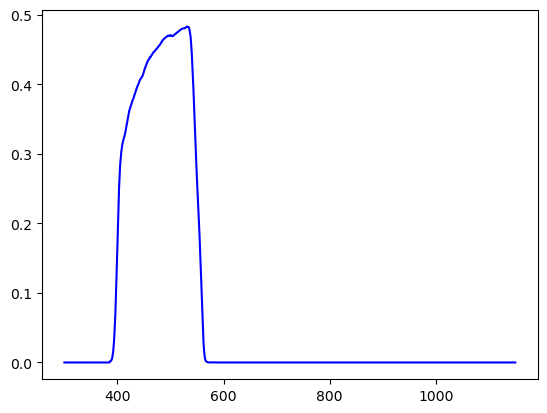

In [10]:
band = 'g'
filter_file = f'filter_files/total_{band}.dat'
filter_band = np.loadtxt(filter_file).T #filter_band[0] -> wavelengths, filter_band[1] -> filter pass fraction

wave = filter_band[0]
S = filter_band[1]
plt.plot(filter_band[0], filter_band[1], color = colors[band])


mean_wavelength = np.sum(wave * S) / np.sum(S)
print(f'Mean wavelength of {band} band: {mean_wavelength} Angstroms')


mean_wavelength = scipy.integrate.simpson(S, wave) / scipy.integrate.simpson(S / wave, wave)
print(f'Mean wavelength of {band} band: {mean_wavelength} Angstroms')

Mean frequency of g band: 629302112146868.4 Hz
Mean wavelength of g band: 476.7185652318057 nm


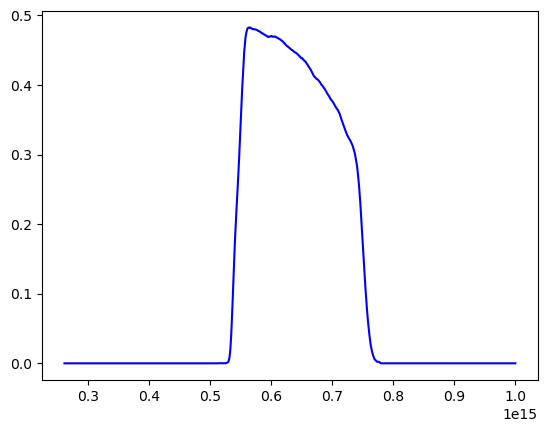

In [11]:
c = 3e8 * 10**9 #nm/s
f = c / (filter_band[0])
plt.plot(f, filter_band[1], color = colors[band])

mean_frequency = np.sum(f * S) / np.sum(S)
print(f'Mean frequency of {band} band: {mean_frequency} Hz') 
print(f'Mean wavelength of {band} band: {c / mean_frequency} nm')